# Exploration vs. Exploitation: epsilon-greedy vs Boltzmann softmax

Side-by-side comparison of two action-selection rules used during DQN training on the Coup Markov transition dataset.

- **epsilon_greedy**: with probability `epsilon` take a uniform random action, otherwise argmax Q. Explores uniformly.
- **softmax** (Boltzmann): sample actions from `softmax(Q / tau)` with annealed temperature `tau`. Explores in proportion to Q-value spread (entropy-regularised).

Both share the same seed, network architecture, replay buffer, and reward.

## 0) Setup

In [1]:
from pathlib import Path
import csv
import json
import os

ROOT = Path.cwd()
if not (ROOT / 'coup').exists():
    fallback = Path('/Users/crishuynh/Documents/SoftwareProject/coup_detection')
    if (fallback / 'coup').exists():
        ROOT = fallback
os.chdir(ROOT)

MARKOV_CSV = ROOT / 'data' / 'research' / 'markov_transitions.csv'
OUT_EG = ROOT / 'data' / 'research' / 'dqn_exploration' / 'epsilon_greedy'
OUT_SM = ROOT / 'data' / 'research' / 'dqn_exploration' / 'softmax'
OUT_EG.parent.mkdir(parents=True, exist_ok=True)

EPISODES = 500
SEED = 42
print('Markov CSV exists:', MARKOV_CSV.exists())

Markov CSV exists: True


## 1) Train both DQNs with matched seed

In [2]:
from coup.research.rl_train import train_dqn_policy

summary_eg = train_dqn_policy(
    transitions_csv=MARKOV_CSV,
    out_dir=OUT_EG,
    episodes=EPISODES,
    seed=SEED,
    exploration_mode='epsilon_greedy',
)

summary_sm = train_dqn_policy(
    transitions_csv=MARKOV_CSV,
    out_dir=OUT_SM,
    episodes=EPISODES,
    seed=SEED,
    exploration_mode='softmax',
    tau_start=1.0,
    tau_end=0.1,
    tau_decay=0.995,
)

print('epsilon_greedy:', json.dumps(summary_eg['train_metrics'], indent=2))
print('softmax:       ', json.dumps(summary_sm['train_metrics'], indent=2))

epsilon_greedy: {
  "episodes": 500,
  "avg_episode_reward": 16.278,
  "avg_episode_steps": 24.46,
  "final_epsilon": 0.08157186144027828,
  "final_tau": 0.1,
  "exploration_mode": "epsilon_greedy",
  "avg_action_entropy": 1.075944955607808
}
softmax:        {
  "episodes": 500,
  "avg_episode_reward": 16.51,
  "avg_episode_steps": 24.46,
  "final_epsilon": 0.08157186144027828,
  "final_tau": 0.1,
  "exploration_mode": "softmax",
  "avg_action_entropy": 1.1766791545974977
}


## 2) Load per-episode training histories

In [3]:
import pandas as pd

hist_eg = pd.read_csv(OUT_EG / 'train_episode_history.csv')
hist_sm = pd.read_csv(OUT_SM / 'train_episode_history.csv')
hist_eg.head()

,episode,reward,steps,epsilon,tau,exploration_mode,action_entropy,avg_reward_so_far
0,1,21.0,26,1.000000,1.000000,epsilon_greedy,1.945910,21.00
1,2,14.0,19,0.995000,0.995000,epsilon_greedy,1.945836,17.50
2,3,7.0,16,0.990025,0.990025,epsilon_greedy,1.945616,14.00
3,4,13.0,30,0.985075,0.985075,epsilon_greedy,1.945258,13.75
4,5,18.0,25,0.980150,0.980150,epsilon_greedy,1.944765,14.60


## 3) Reward curves

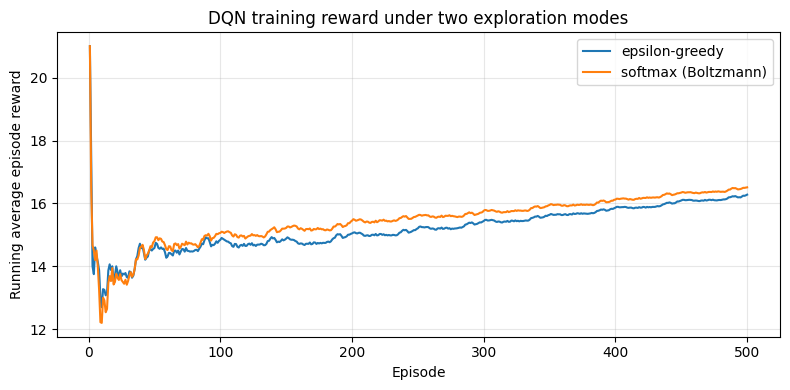

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_eg['episode'], hist_eg['avg_reward_so_far'], label='epsilon-greedy')
ax.plot(hist_sm['episode'], hist_sm['avg_reward_so_far'], label='softmax (Boltzmann)')
ax.set_xlabel('Episode')
ax.set_ylabel('Running average episode reward')
ax.set_title('DQN training reward under two exploration modes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4) Action-entropy curves

`action_entropy` is the mean per-step Shannon entropy of the policy's action distribution at that episode. Higher = more exploration.

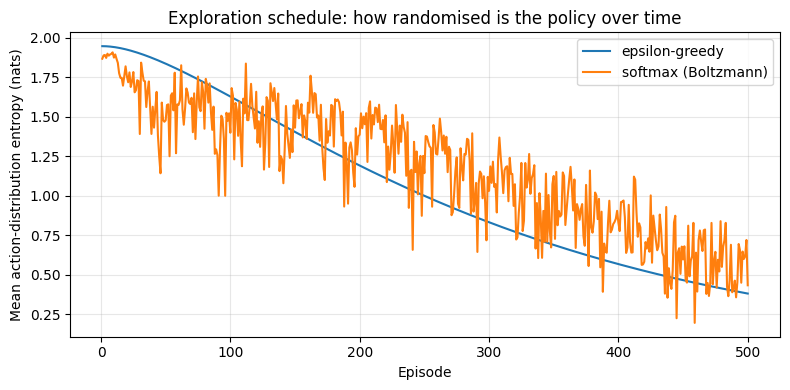

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_eg['episode'], hist_eg['action_entropy'], label='epsilon-greedy')
ax.plot(hist_sm['episode'], hist_sm['action_entropy'], label='softmax (Boltzmann)')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean action-distribution entropy (nats)')
ax.set_title('Exploration schedule: how randomised is the policy over time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5) Action-count distributions

Did the two modes visit different actions during training?

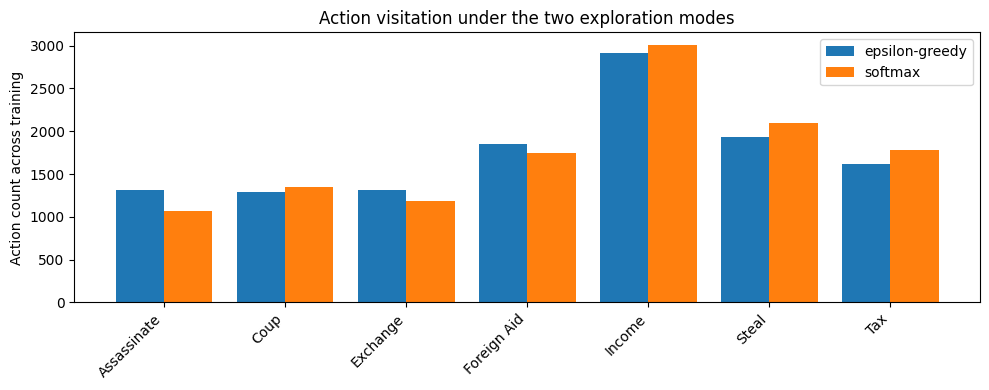

In [6]:
counts_eg = json.loads((OUT_EG / 'train_action_counts.json').read_text())
counts_sm = json.loads((OUT_SM / 'train_action_counts.json').read_text())

labels = sorted(set(counts_eg) | set(counts_sm))
eg_vals = [counts_eg.get(lbl, 0) for lbl in labels]
sm_vals = [counts_sm.get(lbl, 0) for lbl in labels]

import numpy as np
x = np.arange(len(labels))
width = 0.4
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, eg_vals, width, label='epsilon-greedy')
ax.bar(x + width / 2, sm_vals, width, label='softmax')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Action count across training')
ax.set_title('Action visitation under the two exploration modes')
ax.legend()
plt.tight_layout()
plt.show()

## 6) Benchmark summary

In [7]:
rows = []
for mode, summary in [('epsilon_greedy', summary_eg), ('softmax', summary_sm)]:
    bench = summary.get('benchmark', {}).get('dqn_policy', {})
    rows.append({
        'exploration_mode': mode,
        'avg_reward_per_episode': bench.get('avg_reward_per_episode'),
        'avg_reward_per_step': bench.get('avg_reward_per_step'),
        'action_match_rate': bench.get('action_match_rate'),
        'avg_action_entropy': summary.get('train_metrics', {}).get('avg_action_entropy'),
    })
pd.DataFrame(rows)

,exploration_mode,avg_reward_per_episode,avg_reward_per_step,action_match_rate,avg_action_entropy
0,epsilon_greedy,17.54,0.717089,0.257563,1.075945
1,softmax,19.56,0.799673,0.340147,1.176679


## Notes for the paper

- Cite this notebook's figures in the Results section (paper.tex L614).
- Entropy curves visualise the *exploration schedule* directly — epsilon-greedy entropy is monotone in `epsilon`; softmax entropy is monotone in `tau` but also responds to Q-value spread, so it can plateau above the floor.
- If the softmax benchmark is competitive with epsilon-greedy at matched steps, that is evidence that proportional exploration is a viable alternative. If it wins, it supports the Discussion argument (paper.tex L764) that deterministic threshold advisors leave value on the table.